In [1]:
import os
import json
import glob
import re
import logging
from collections import defaultdict
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
path = "/mbz/users/liyuan/LLaMA-Factory/results/data_mixing"
experiment_name = "exp1"
base_model = "Llama-3.2-3B"
base_token = 6600000
domains = ["instr", "math", "code"]

In [2]:
# Define the root directory containing the results
ROOT_DIR = "/mbz/users/liyuan/LLaMA-Factory/results/data_mixing/exp1/Llama-3.2-3B/660000_5"

# Define the domains
DOMAINS = ["instr", "math", "code"]

SIZES = ["third", "half", "one", "double", "triple"]
model = "Llama-3.2-3B"

In [5]:
# Define the root directory containing the results
ROOT_DIR = "/mbz/users/liyuan/LLaMA-Factory/results/data_mixing/exp1/Llama-3.1-8B/660000"

# Define the domains
DOMAINS = ["instr", "math", "code"]

SIZES = ["third", "half", "one", "double", "triple"]
model = "Llama-3.1-8B"

experiment_name = "exp1"
base_model = "Llama-3.1-8B"
base_token = 6600000
domains = ["instr", "math", "code"]

In [4]:
results = []

# ------------------------------
# Main Processing Loop
# ------------------------------

for domain in DOMAINS:
    for size in SIZES:
        acc_ppl = 0.0  # Accumulator for perplexity
        
        for val_domain in DOMAINS:
            # Determine the other two domains excluding the current domain
            other_domains = [d for d in DOMAINS if d != domain]
            
            # Construct the filename based on the provided pattern
            filename = (
                f"ppl_{val_domain}_val_{model}_{domain}_{size}_"
                f"{other_domains[0]}_one_{other_domains[1]}_one.json"
            )
            
            # Full path to the JSON file
            filepath = os.path.join(ROOT_DIR, domain, filename)
            
            # Check if the file exists to avoid FileNotFoundError
            if not os.path.isfile(filepath):
                print(f"Warning: File not found: {filepath}. Skipping this file.")
                continue  # Skip to the next validation domain
            
            # Load the JSON data
            try:
                with open(filepath, 'r') as f:
                    data = json.load(f)
            except json.JSONDecodeError:
                print(f"Error: JSON decoding failed for file: {filepath}. Skipping this file.")
                continue  # Skip to the next validation domain
            except Exception as e:
                print(f"Error: An unexpected error occurred while reading {filepath}: {e}. Skipping this file.")
                continue  # Skip to the next validation domain
            
            try:
                # Assuming 'data' is a list and the first element contains the metric
                token_ppl = data[0]["token-level ppl"]
            except (IndexError, KeyError, TypeError):
                print(f"Error: 'token-level ppl' not found or malformed in file: {filepath}. Skipping this file.")
                continue  # Skip to the next validation domain
            
            # Accumulate the perplexity
            acc_ppl += token_ppl
        
        # Calculate the average perplexity
        # Determine how many validation domains were successfully processed
        # This is important in case some files were missing or had errors
        valid_val_domains = len([d for d in DOMAINS if os.path.isfile(os.path.join(ROOT_DIR, domain, 
            f"ppl_{d}_val_{model}_{domain}_{size}_{[x for x in DOMAINS if x != domain][0]}_one_{[x for x in DOMAINS if x != domain][1]}_one.json"))])
        
        if valid_val_domains > 0:
            avg_ppl = acc_ppl / valid_val_domains
        else:
            avg_ppl = None  # Or some default value or indicator for missing data
        
        # Create the result dictionary
        result = {   
            "domain": domain,
            "size": size,
            "avg_ppl": avg_ppl
        }
        
        # Append the result to the results list
        results.append(result)

# ------------------------------
# Output the Results
# ------------------------------

# Optionally, print the results
for entry in results:
    print(entry)

# If you want to use the results further, you can keep them in the 'results' list
# For example, you could save them to a JSON file:
# output_path = os.path.join(ROOT_DIR, "average_validation_metrics.json")
# with open(output_path, 'w') as outfile:
#     json.dump(results, outfile, indent=4)

# print(f"\nAll average validation metrics have been saved to {output_path}")

{'domain': 'instr', 'size': 'third', 'avg_ppl': 2.3009398127536653}
{'domain': 'instr', 'size': 'half', 'avg_ppl': 2.2919550197611414}
{'domain': 'instr', 'size': 'one', 'avg_ppl': 2.260249565503622}
{'domain': 'instr', 'size': 'double', 'avg_ppl': 2.2253171055400482}
{'domain': 'instr', 'size': 'triple', 'avg_ppl': 2.2078428253445472}
{'domain': 'math', 'size': 'third', 'avg_ppl': 2.2891207768582373}
{'domain': 'math', 'size': 'half', 'avg_ppl': 2.275715067349909}
{'domain': 'math', 'size': 'one', 'avg_ppl': 2.2594541371216224}
{'domain': 'math', 'size': 'double', 'avg_ppl': 2.2340252519100123}
{'domain': 'math', 'size': 'triple', 'avg_ppl': 2.2223123883020706}
{'domain': 'code', 'size': 'third', 'avg_ppl': 2.2946755321189904}
{'domain': 'code', 'size': 'half', 'avg_ppl': 2.2822197449260098}
{'domain': 'code', 'size': 'one', 'avg_ppl': 2.2601072040502985}
{'domain': 'code', 'size': 'double', 'avg_ppl': 2.2327336034851544}
{'domain': 'code', 'size': 'triple', 'avg_ppl': 2.2183251314478

In [8]:
ROOT_DIR = "/mbz/users/liyuan/LLaMA-Factory/results/data_mixing/exp1/Llama-3.1-8B/660000"

results = []

# ------------------------------
# Main Processing Loop
# ------------------------------

for domain in DOMAINS:
    for size in SIZES:
        acc_ppl = 0.0  # Accumulator for perplexity
        
        for val_domain in DOMAINS:
            # Determine the other two domains excluding the current domain
            other_domains = [d for d in DOMAINS if d != domain]
            
            # Construct the filename based on the provided pattern
            filename = (
                f"ppl_5000000_{val_domain}_val_{model}_{domain}_{size}_"
                f"{other_domains[0]}_one_{other_domains[1]}_one.json"
            )
            
            # Full path to the JSON file
            filepath = os.path.join(ROOT_DIR, domain, filename)
            
            # Check if the file exists to avoid FileNotFoundError
            if not os.path.isfile(filepath):
                print(f"Warning: File not found: {filepath}. Skipping this file.")
                continue  # Skip to the next validation domain
            
            # Load the JSON data
            try:
                with open(filepath, 'r') as f:
                    data = json.load(f)
            except json.JSONDecodeError:
                print(f"Error: JSON decoding failed for file: {filepath}. Skipping this file.")
                continue  # Skip to the next validation domain
            except Exception as e:
                print(f"Error: An unexpected error occurred while reading {filepath}: {e}. Skipping this file.")
                continue  # Skip to the next validation domain
            
            try:
                # Assuming 'data' is a list and the first element contains the metric
                token_ppl = data[0]["token-level ppl"]
            except (IndexError, KeyError, TypeError):
                print(f"Error: 'token-level ppl' not found or malformed in file: {filepath}. Skipping this file.")
                continue  # Skip to the next validation domain
            
            # Accumulate the perplexity
            acc_ppl += token_ppl
        
        # Calculate the average perplexity
        # Determine how many validation domains were successfully processed
        # This is important in case some files were missing or had errors
        valid_val_domains = len([d for d in DOMAINS if os.path.isfile(os.path.join(ROOT_DIR, domain, 
            f"ppl_5000000_{d}_val_{model}_{domain}_{size}_{[x for x in DOMAINS if x != domain][0]}_one_{[x for x in DOMAINS if x != domain][1]}_one.json"))])
        
        if valid_val_domains > 0:
            avg_ppl = acc_ppl / valid_val_domains
        else:
            avg_ppl = None  # Or some default value or indicator for missing data
        
        # Create the result dictionary
        result = {   
            "domain": domain,
            "size": size,
            "avg_ppl": avg_ppl
        }
        
        # Append the result to the results list
        results.append(result)

# ------------------------------
# Output the Results
# ------------------------------

# Optionally, print the results
print("660 results for llama8B")
for entry in results:
    
    print(entry)


660 results for llama8B
{'domain': 'instr', 'size': 'third', 'avg_ppl': 2.3344510239838225}
{'domain': 'instr', 'size': 'half', 'avg_ppl': 2.332892905356599}
{'domain': 'instr', 'size': 'one', 'avg_ppl': 2.2976380169368458}
{'domain': 'instr', 'size': 'double', 'avg_ppl': 2.261286674352709}
{'domain': 'instr', 'size': 'triple', 'avg_ppl': 2.251291523597417}
{'domain': 'math', 'size': 'third', 'avg_ppl': 2.3217512425787867}
{'domain': 'math', 'size': 'half', 'avg_ppl': 2.315506112513719}
{'domain': 'math', 'size': 'one', 'avg_ppl': 2.305486517203082}
{'domain': 'math', 'size': 'double', 'avg_ppl': 2.2779459045407386}
{'domain': 'math', 'size': 'triple', 'avg_ppl': 2.2546816253283204}
{'domain': 'code', 'size': 'third', 'avg_ppl': 2.316531607957455}
{'domain': 'code', 'size': 'half', 'avg_ppl': 2.307071547605066}
{'domain': 'code', 'size': 'one', 'avg_ppl': 2.3087366492973}
{'domain': 'code', 'size': 'double', 'avg_ppl': 2.2700898714762863}
{'domain': 'code', 'size': 'triple', 'avg_ppl':

In [4]:
results = []

# ------------------------------
# Main Processing Loop
# ------------------------------

for domain in DOMAINS:
    for size in SIZES:
        acc_ppl = 0.0  # Accumulator for perplexity
        
        for val_domain in DOMAINS:
            # Determine the other two domains excluding the current domain
            other_domains = [d for d in DOMAINS if d != domain]
            
            # Construct the filename based on the provided pattern
            filename = (
                f"ppl_{val_domain}_val_{model}_{domain}_{size}_"
                f"{other_domains[0]}_one_{other_domains[1]}_one.json"
            )
            
            # Full path to the JSON file
            filepath = os.path.join(ROOT_DIR, domain, filename)
            
            # Check if the file exists to avoid FileNotFoundError
            if not os.path.isfile(filepath):
                print(f"Warning: File not found: {filepath}. Skipping this file.")
                continue  # Skip to the next validation domain
            
            # Load the JSON data
            try:
                with open(filepath, 'r') as f:
                    data = json.load(f)
            except json.JSONDecodeError:
                print(f"Error: JSON decoding failed for file: {filepath}. Skipping this file.")
                continue  # Skip to the next validation domain
            except Exception as e:
                print(f"Error: An unexpected error occurred while reading {filepath}: {e}. Skipping this file.")
                continue  # Skip to the next validation domain
            
            try:
                # Assuming 'data' is a list and the first element contains the metric
                token_ppl = data[0]["token-level ppl"]
            except (IndexError, KeyError, TypeError):
                print(f"Error: 'token-level ppl' not found or malformed in file: {filepath}. Skipping this file.")
                continue  # Skip to the next validation domain
            
            # Accumulate the perplexity
            acc_ppl += token_ppl
        
        # Calculate the average perplexity
        # Determine how many validation domains were successfully processed
        # This is important in case some files were missing or had errors
        valid_val_domains = len([d for d in DOMAINS if os.path.isfile(os.path.join(ROOT_DIR, domain, 
            f"ppl_{d}_val_{model}_{domain}_{size}_{[x for x in DOMAINS if x != domain][0]}_one_{[x for x in DOMAINS if x != domain][1]}_one.json"))])
        
        if valid_val_domains > 0:
            avg_ppl = acc_ppl / valid_val_domains
        else:
            avg_ppl = None  # Or some default value or indicator for missing data
        
        # Create the result dictionary
        result = {   
            "domain": domain,
            "size": size,
            "avg_ppl": avg_ppl
        }
        
        # Append the result to the results list
        results.append(result)

# ------------------------------
# Output the Results
# ------------------------------

# Optionally, print the results
print("660 results for llama8B")
for entry in results:
    
    print(entry)


660 results for llama8B
{'domain': 'instr', 'size': 'third', 'avg_ppl': 2.262133190042021}
{'domain': 'instr', 'size': 'half', 'avg_ppl': 2.268651668846584}
{'domain': 'instr', 'size': 'one', 'avg_ppl': 2.24860813834489}
{'domain': 'instr', 'size': 'double', 'avg_ppl': 2.2374186036289854}
{'domain': 'instr', 'size': 'triple', 'avg_ppl': 2.2304256326869805}
{'domain': 'math', 'size': 'third', 'avg_ppl': 2.282574817052204}
{'domain': 'math', 'size': 'half', 'avg_ppl': 2.255508926510795}
{'domain': 'math', 'size': 'one', 'avg_ppl': 2.247996610369668}
{'domain': 'math', 'size': 'double', 'avg_ppl': 2.23818165034097}
{'domain': 'math', 'size': 'triple', 'avg_ppl': 2.2381429227144665}
{'domain': 'code', 'size': 'third', 'avg_ppl': 2.311230037162437}
{'domain': 'code', 'size': 'half', 'avg_ppl': 2.2747070035836745}
{'domain': 'code', 'size': 'one', 'avg_ppl': 2.2549156492121742}
{'domain': 'code', 'size': 'double', 'avg_ppl': 2.2251416028890385}
{'domain': 'code', 'size': 'triple', 'avg_ppl':

In [5]:
def create_perplexity_matrix(df, size, domains):
    """
    Creates a 3x3 perplexity matrix for the specified size.

    Parameters:
    - df (pd.DataFrame): The DataFrame containing results.
    - size (str): The size filter ('one' or 'triple').
    - domains (list): List of domain names.

    Returns:
    - pd.DataFrame: Pivoted 3x3 perplexity matrix.
    """
    # Filter the DataFrame for the specified size
    df_size = df[df['size'] == size]
    
    # Pivot the DataFrame to create a matrix
    matrix = df_size.pivot(index='train_domain', columns='val_domain', values='token_ppl')
    
    # Reindex to ensure consistent ordering
    matrix = matrix.reindex(index=domains, columns=domains)
    
    return matrix

# Define the domains
domains = ['instr', 'math', 'code']

# Create matrices for size 'one' and 'triple'
matrix_one = create_perplexity_matrix(df, 'one', domains)
matrix_triple = create_perplexity_matrix(df, 'triple', domains)

# ------------------------------
# Output the Perplexity Matrices
# ------------------------------

print("\n3×3 Token-Level Perplexity Matrix (Training on Single Domain - Size 'one'):\n")
print(matrix_triple - matrix_one)


NameError: name 'df' is not defined

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_heatmap(matrix, title, figsize=(5, 4), dpi=50, cmap="coolwarm"):
    """
    Plots a heatmap with enhanced resolution, simple font, and customized colors.

    Parameters:
    - matrix (pd.DataFrame): The DataFrame containing the matrix data.
    - title (str): The title of the heatmap.
    - figsize (tuple): Figure size in inches. Default is (10, 8).
    - dpi (int): Resolution of the figure in dots per inch. Default is 300.
    - cmap (str): Color map to use for the heatmap. Default is "coolwarm".

    Returns:
    - None
    """
    # Set the style
    sns.set(style="whitegrid")  # Use white grid background for better contrast

    # Create a figure with the specified size and resolution
    plt.figure(figsize=figsize, dpi=dpi)

    # Define font properties
    font = {
        # 'family': 'Arial',       # Simple sans-serif font
        'weight': 'normal',
        'size': 14
    }

    # Apply font settings
    plt.rc('font', **font)

    # Create the heatmap
    heatmap = sns.heatmap(
        matrix,
        annot=True,                   # Annotate cells with data
        fmt=".2f",                    # Format for annotations
        cmap=cmap,                    # Color palette
        cbar=True,                    # Show color bar
        linewidths=0.5,               # Line width between cells
        linecolor='white',            # Line color
        annot_kws={"size": 12, "weight": "bold"},  # Annotation font size and weight
        square=True,                  # Make cells square-shaped
        cbar_kws={"shrink": 0.75, "aspect": 30}    # Adjust color bar size
    )

    # Set title and labels with enhanced font sizes
    plt.title(title, fontsize=18, weight='bold', pad=20)
    plt.xlabel("Validation Domain", fontsize=16, weight='bold', labelpad=15)
    plt.ylabel("Training Domain", fontsize=16, weight='bold', labelpad=15)

    # Adjust tick labels
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(rotation=0, fontsize=12)

    # Improve layout to prevent clipping of tick-labels
    plt.tight_layout()

    # Optionally, save the plot to a file with the specified DPI
    # Uncomment the following lines to save the plot
    # save_path = "heatmap.png"
    # plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    # print(f"Heatmap saved to {save_path}")

    # Display the plot
    plt.savefig(f"{title}.png")
    plt.show()
    

# ------------------------------
# Usage Example
# ------------------------------

# Define the matrix data
data = {
    'instr': {'instr': -0.133185, 'math': -0.001072, 'code': -0.022964},
    'math': {'instr': -0.030869, 'math': -0.065745, 'code': -0.014811},
    'code': {'instr': -0.047750, 'math': -0.013192, 'code': -0.064404}
}

# Create the DataFrame
df = pd.DataFrame(data)

# Print the DataFrame to verify




DataFrame:
            IF      Math      Code
IF   -0.133185 -0.030869 -0.047750
Math -0.001072 -0.065745 -0.013192
Code -0.022964 -0.014811 -0.064404


Heatmap saved to heatmaps/perplexity_heatmap.pdf


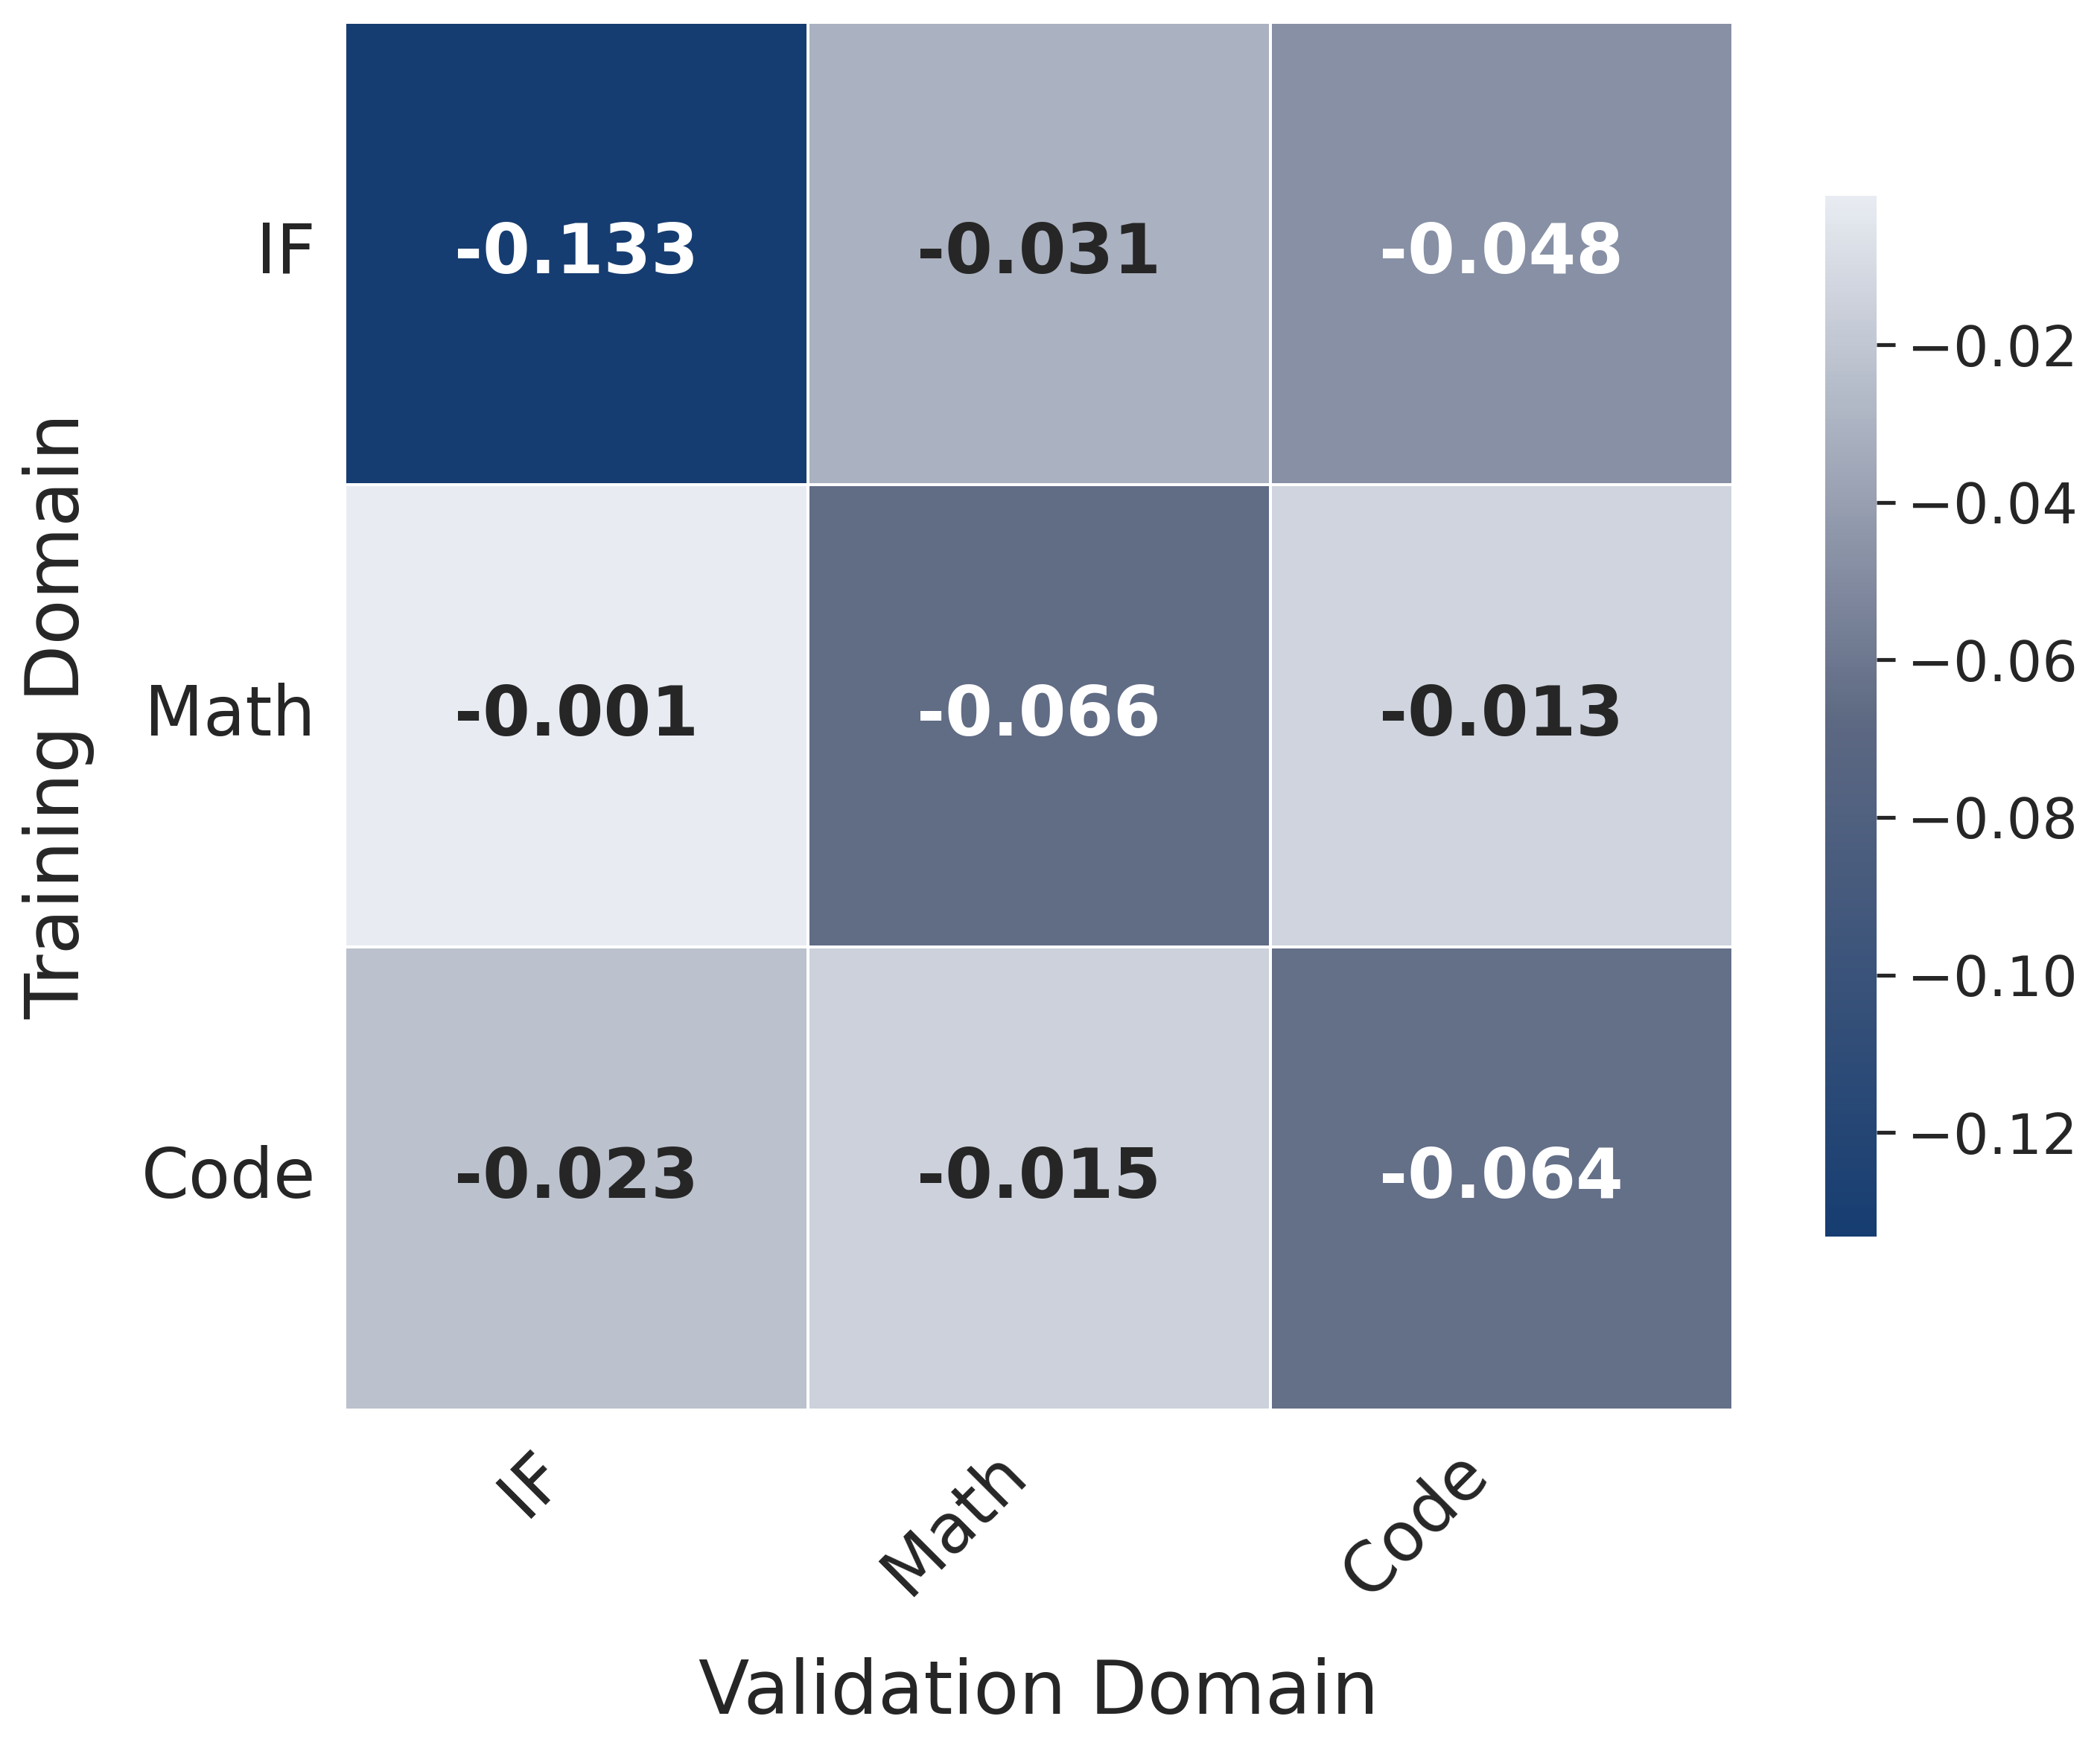

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os

def create_custom_blue_cmap():
    """
    Creates a custom blue colormap transitioning from light blue to dark blue.

    Returns:
    - custom_blue (LinearSegmentedColormap): The custom blue colormap.
    """
    # Define the colors: light blue to dark blue
    colors = [
        # "#d1dae5",  # Dark Blue
        "#163d71",
        # "#5d7ca4",
        # "#626c86",
        "#5e6983",  
        "#e8ecf2",  # Steel Blue
          # Sky Blue
        # "#18447d",  # Light Blue
        
    ]
    
    # Create the colormap
    custom_blue = LinearSegmentedColormap.from_list("custom_blue", colors, N=256)
    
    return custom_blue

def visualize_custom_cmap(cmap):
    """
    Visualizes the custom color map.

    Parameters:
    - cmap (LinearSegmentedColormap): The colormap to visualize.

    Returns:
    - None
    """
    gradient = pd.DataFrame([range(256)])
    plt.figure(figsize=(6, 2))
    sns.heatmap(gradient, cmap=cmap, cbar=False)
    plt.title("Custom Blue Color Map", fontsize=14, weight='bold', pad=10)
    plt.axis('off')
    plt.show()

def plot_heatmap(matrix, cmap, figsize=(10, 8), dpi=300, save_path=None):
    """
    Plots a heatmap with enhanced resolution and customizable colors.

    Parameters:
    - matrix (pd.DataFrame): The DataFrame containing the matrix data.
    - title (str): The title of the heatmap.
    - cmap (LinearSegmentedColormap or str): Custom color map or predefined palette.
    - figsize (tuple): Figure size in inches. Default is (10, 8).
    - dpi (int): Resolution of the figure in dots per inch. Default is 300.
    - save_path (str): If provided, saves the plot to the specified path.

    Returns:
    - None
    """
    # Set the style
    sns.set(style="whitegrid")  # Use white grid background for better contrast

    # Create a figure with the specified size and resolution
    plt.figure(figsize=figsize, dpi=dpi)

    # Create the heatmap
    heatmap = sns.heatmap(
        matrix,
        annot=True,                   # Annotate cells with data
        fmt=".3f",                   # Format for annotations
        cmap=cmap,                   # Custom color palette
        cbar=True,                   # Show color bar
        linewidths=0.5,              # Line width between cells
        linecolor='white',           # Line color
        annot_kws={"size": 22, "weight": "bold"},  # Annotation font size and weight
        square=True,                 # Make cells square-shaped
        cbar_kws={"shrink": 0.75, "aspect": 20}    # Adjust color bar size
    )
    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=18)
    # Set title and labels with enhanced font sizes
    plt.xlabel("Validation Domain", fontsize=24, labelpad=15)
    plt.ylabel("Training Domain", fontsize=24, labelpad=15)

    # Adjust tick labels
    plt.xticks(rotation=45, ha='right', fontsize=22)
    plt.yticks(rotation=0, fontsize=22)

    # Improve layout to prevent clipping of tick-labels
    plt.tight_layout()

    # Optionally, save the plot to a file with the specified DPI
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Heatmap saved to {save_path}")

    # Display the plot
    plt.show()

# ------------------------------
# Usage Example
# ------------------------------

# Define the matrix data
data = {
    'IF': {'IF': -0.133185, 'Math': -0.001072, 'Code': -0.022964},
    'Math': {'IF': -0.030869, 'Math': -0.065745, 'Code': -0.014811},
    'Code': {'IF': -0.047750, 'Math': -0.013192, 'Code': -0.064404}
}

# Create the DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print("DataFrame:")
print(df)

# Create the custom blue colormap
custom_blue = create_custom_blue_cmap()

# Optional: Visualize the custom blue colormap to verify
# Uncomment the following line to see the color gradient
# visualize_custom_cmap(custom_blue)

# Define the title

# Define the path to save the heatmap (optional)
save_directory = "heatmaps"
os.makedirs(save_directory, exist_ok=True)
save_path = os.path.join(save_directory, "perplexity_heatmap.pdf")

# Plot the heatmap using the custom blue color map
plot_heatmap(
    matrix=df,
    cmap=custom_blue,            # Use the custom blue color map
    figsize=(10, 8),# Larger figure size for better visibility
    dpi=300,                     # Higher resolution suitable for publications
    save_path=save_path          # Save the plot to the specified path
)

